# Lab 2: Predicting Late Invoice Payments (Accounts Receivable)

## Business Context

In ERP systems, the **Accounts Receivable (AR)** module manages customer invoices and payments. Companies often want to **predict which invoices are likely to be paid late** so they can:

- prioritize collections
- adjust credit policies
- reduce cash-flow risk

In this lab, we build a **machine learning classification model** that predicts whether an invoice will be paid late.

## Learning Objectives

By the end of this lab, you should be able to:

- understand how machine learning can support ERP financial processes
- perform feature engineering on business data
- train and evaluate a classification model
- interpret results in business terms

## 0. Preparing Data

### Step 1. Import Libraries

In [581]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

# pandas is used for working with tables of data (DataFrames)
import pandas as pd

# numpy is used for numerical operations
import numpy as np

# matplotlib is the basic plotting library
import matplotlib.pyplot as plt

# seaborn makes plots look nicer and easier to create
import seaborn as sns

# train_test_split is used to split data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler can be used to scale numeric features
# We import it here for completeness, though it is optional in this notebook
from sklearn.preprocessing import StandardScaler

# Evaluation metrics for classification
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Two classification models:
# 1. Logistic Regression - a simple and common baseline classifier
# 2. Random Forest - a stronger tree-based ensemble model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# This line tells matplotlib to display plots inside the notebook
%matplotlib inline

### Step 2. Load the Dataset from Google Drive

In [582]:
# ============================================================
# STEP 2: UPLOAD THE DATASET IN COLAB
# ============================================================

import pandas as pd
from google.colab import drive
import os

drive.mount('/content/drive')

# Update the path to your file in Google Drive
folder_path = "/content/drive/My Drive/cpe494-lab/data-lab2/"
file_name = "WA_Fn-UseC_-Accounts-Receivable.csv"
file_path = folder_path + file_name

# Check if the file exists at the specified path
if os.path.exists(file_path):

    print("Reading dataset file...")
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    print("...done reading dataset file")

    #show the first 5 rows to inspect the data
    print(df.head())

else:
    print(f"Error: File not found at {file_path}")
    print("Please check the path and filename.")

    # List contents of the directory to help debug
    directory_path = os.path.dirname(file_path)
    if os.path.exists(directory_path):
        print(f"Contents of directory '{directory_path}':")
        for item in os.listdir(directory_path):
            print(f"- {item}")
    else:
        print(f"Error: Directory '{directory_path}' not found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading dataset file...
...done reading dataset file
   countryCode  customerID PaperlessDate  invoiceNumber InvoiceDate  \
0          391  0379-NEVHP      4/6/2013         611365    1/2/2013   
1          406  8976-AMJEO      3/3/2012        7900770   1/26/2013   
2          391  2820-XGXSB     1/26/2012        9231909    7/3/2013   
3          406  9322-YCTQO      4/6/2012        9888306   2/10/2013   
4          818  6627-ELFBK    11/26/2012       15752855  10/25/2012   

      DueDate  InvoiceAmount Disputed SettledDate PaperlessBill  DaysToSettle  \
0    2/1/2013          55.94       No   1/15/2013         Paper            13   
1   2/25/2013          61.74      Yes    3/3/2013    Electronic            36   
2    8/2/2013          65.88       No    7/8/2013    Electronic             5   
3   3/12/2013         105.92       No   3/17/2013    Electronic    

### Step 3. Inspect the Dataset Structure

In [583]:
# ============================================================
# STEP 3A: BASIC SHAPE AND COLUMN NAMES
# ============================================================

# Display the number of rows and columns
print("Dataset shape:", df.shape)

# Display all column names
print("\nColumn names:")
for col in df.columns:
    print("-", col)

Dataset shape: (2466, 12)

Column names:
- countryCode
- customerID
- PaperlessDate
- invoiceNumber
- InvoiceDate
- DueDate
- InvoiceAmount
- Disputed
- SettledDate
- PaperlessBill
- DaysToSettle
- DaysLate


In [584]:
# ============================================================
# STEP 3B: DATA TYPES AND MISSING VALUES
# ============================================================

# info() shows column names, non-null counts, and data types
print("DataFrame info:")
df.info()

# Count missing values in each column
print("\nMissing values by column:")
print(df.isnull().sum())

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryCode    2466 non-null   int64  
 1   customerID     2466 non-null   object 
 2   PaperlessDate  2466 non-null   object 
 3   invoiceNumber  2466 non-null   int64  
 4   InvoiceDate    2466 non-null   object 
 5   DueDate        2466 non-null   object 
 6   InvoiceAmount  2466 non-null   float64
 7   Disputed       2466 non-null   object 
 8   SettledDate    2466 non-null   object 
 9   PaperlessBill  2466 non-null   object 
 10  DaysToSettle   2466 non-null   int64  
 11  DaysLate       2466 non-null   int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 231.3+ KB

Missing values by column:
countryCode      0
customerID       0
PaperlessDate    0
invoiceNumber    0
InvoiceDate      0
DueDate          0
InvoiceAmount    0
Disputed         0
SettledDate      0

In [585]:
# ============================================================
# STEP 3C: DESCRIPTIVE STATISTICS FOR NUMERIC COLUMNS
# ============================================================

# describe() summarizes numeric columns
df.describe()

,countryCode,invoiceNumber,InvoiceAmount,DaysToSettle,DaysLate
count,2466.000000,2.466000e+03,2466.000000,2466.00000,2466.000000
mean,620.446067,4.978431e+09,59.895856,26.44485,3.442417
std,215.933610,2.884272e+09,20.435838,12.33493,6.290607
min,391.000000,6.113650e+05,5.260000,0.00000,0.000000
25%,406.000000,2.528854e+09,46.400000,18.00000,0.000000
50%,770.000000,4.964228e+09,60.560000,26.00000,0.000000
75%,818.000000,7.494512e+09,73.765000,35.00000,5.000000
max,897.000000,9.990244e+09,128.280000,75.00000,45.000000


### Step 4. Understand the Business Problem and Target Variable

The goal is to predict:

- `late_payment = 1` if the invoice was paid late
- `late_payment = 0` if the invoice was paid on time

To do that, we usually need three dates:

- invoice date
- due date
- payment date

From these, we can engineer:

- `days_to_pay` = payment_date - invoice_date
- `allowed_days` = due_date - invoice_date
- `late_payment` = whether `days_to_pay > allowed_days`

In [586]:
# ============================================================
# STEP 4A: LOOK FOR POSSIBLE DATE COLUMNS
# ============================================================

# This is a helper step. It searches for column names that may relate to dates.
# If your dataset has different names than expected, this can help you identify them.

possible_date_cols = [
    col for col in df.columns
    if "date" in col.lower() or "dt" in col.lower()
]

print("Possible date-related columns:")
print(possible_date_cols)

Possible date-related columns:
['PaperlessDate', 'InvoiceDate', 'DueDate', 'SettledDate']


### Step 5. Set the Main Column Names

This notebook assumes the following logical fields exist:

- `invoice_date`
- `due_date`
- `payment_date`
- `invoice_amount`

In [587]:
# ============================================================
# STEP 5: DEFINE IMPORTANT COLUMN NAMES
# ============================================================

# IMPORTANT:
# Replace the strings below if your dataset uses different column names.

invoice_date_col = "InvoiceDate"
due_date_col = "DueDate"
payment_date_col = "SettledDate"
invoice_amount_col = "InvoiceAmount"

# Print them so it is easy to confirm
print("Using these columns:")
print("invoice_date_col =", invoice_date_col)
print("due_date_col     =", due_date_col)
print("payment_date_col =", payment_date_col)
print("invoice_amount_col =", invoice_amount_col)

Using these columns:
invoice_date_col = InvoiceDate
due_date_col     = DueDate
payment_date_col = SettledDate
invoice_amount_col = InvoiceAmount


### Step 6. Convert Date Columns to Datetime

In [588]:
# ============================================================
# STEP 6: CONVERT DATE COLUMNS TO DATETIME
# ============================================================

# Convert the three key date columns to pandas datetime format
# errors="coerce" means invalid date strings become NaT (missing datetime)
df[invoice_date_col] = pd.to_datetime(df[invoice_date_col], errors="coerce")
df[due_date_col] = pd.to_datetime(df[due_date_col], errors="coerce")
df[payment_date_col] = pd.to_datetime(df[payment_date_col], errors="coerce")

# Display a few rows of the converted columns
df[[invoice_date_col, due_date_col, payment_date_col]].head()

,InvoiceDate,DueDate,SettledDate
0,2013-01-02,2013-02-01,2013-01-15
1,2013-01-26,2013-02-25,2013-03-03
2,2013-07-03,2013-08-02,2013-07-08
3,2013-02-10,2013-03-12,2013-03-17
4,2012-10-25,2012-11-24,2012-11-28


### Step 7. Feature Engineering

For both model binary and multi-class

In [589]:
# ============================================================
# STEP 7: CREATE ENGINEERED FEATURES
# ============================================================

# days_to_pay = actual number of days from invoice issue to payment
df["days_to_pay"] = (df[payment_date_col] - df[invoice_date_col]).dt.days

# allowed_days = contractual time allowed before payment is due
df["allowed_days"] = (df[due_date_col] - df[invoice_date_col]).dt.days

# late_payment is our classification target:
# 1 = paid late
# 0 = paid on time
df["late_payment"] = (df["days_to_pay"] > df["allowed_days"]).astype(int)

# Extract month and year from the invoice date
# These can help the model detect seasonal or time-related patterns
df["invoice_month"] = df[invoice_date_col].dt.month
df["invoice_year"] = df[invoice_date_col].dt.year

# Preview the newly created columns
newly_create_cols = [invoice_date_col, due_date_col, payment_date_col,
    "days_to_pay", "allowed_days", "late_payment",
    "invoice_month", "invoice_year"]

df[newly_create_cols].head()

,InvoiceDate,DueDate,SettledDate,days_to_pay,allowed_days,late_payment,invoice_month,invoice_year
0,2013-01-02,2013-02-01,2013-01-15,13,30,0,1,2013
1,2013-01-26,2013-02-25,2013-03-03,36,30,1,1,2013
2,2013-07-03,2013-08-02,2013-07-08,5,30,0,7,2013
3,2013-02-10,2013-03-12,2013-03-17,35,30,1,2,2013
4,2012-10-25,2012-11-24,2012-11-28,34,30,1,10,2012


#### A clear description of your feature engineering, including formulas and code snippets.

- `days_late` = `payment_date` - `due_date`
- `is_late`
  - 1 : late
  - 0 : otherwise
- `invoice_month` = `invoice_date` to month (cell above)
- `days_until_due` = `DueDate` - `InvoiceDate`
- `is_disputed`
  - 1 : Yes
  - 0 : No
- `is_paperless`
  - 1 : Yes
  - 0 : No

- Base on same `customer_id`
  - `customer_prev_invoice_count` = count how many earlier invoices exist before this invoice.
  - `customer_prev_avg_days_late` = average `days_late` over earlier invoices only.
  - `customer_prev_late_ratio` =  proportion of earlier invoices with `days_late` > 0.
  - `customer_prev_avg_invoice_amount` = average `invoice_amount` over earlier invoices only.

In [590]:
# Create the number of days late relative to the due date
# Negative or zero means paid on time or early
# Positive means overdue
df["days_late"] = (df[payment_date_col] - df[due_date_col]).dt.days

df['days_until_due'] = (df[due_date_col] - df[invoice_date_col]).dt.days
df['is_disputed'] = df['Disputed'].map({"Yes" : 1, "No" : 0})
df['is_paperless'] = df['PaperlessBill'].map({"Paper":0, "Electronic":1})

# Base on same Customer ID features
df = df.sort_values(by=['customerID', 'InvoiceDate'])

df['customer_prev_invoice_count'] = df.groupby('customerID').cumcount()
df['customer_prev_avg_days_late'] = df.groupby('customerID')['days_late'].transform(lambda x: x.expanding().mean().shift(1)).fillna(0)

df['is_late'] = (df['days_late'] > 0).astype(int)
df['customer_prev_late_ratio'] = (df.groupby('customerID')['is_late'].transform(lambda x: x.expanding().mean().shift(1)).fillna(0))

df['customer_prev_avg_invoice_amount'] = df.groupby('customerID')['InvoiceAmount'].transform(lambda x: x.expanding().mean().shift(1)).fillna(0)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2466 entries, 991 to 886
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   countryCode                       2466 non-null   int64         
 1   customerID                        2466 non-null   object        
 2   PaperlessDate                     2466 non-null   object        
 3   invoiceNumber                     2466 non-null   int64         
 4   InvoiceDate                       2466 non-null   datetime64[ns]
 5   DueDate                           2466 non-null   datetime64[ns]
 6   InvoiceAmount                     2466 non-null   float64       
 7   Disputed                          2466 non-null   object        
 8   SettledDate                       2466 non-null   datetime64[ns]
 9   PaperlessBill                     2466 non-null   object        
 10  DaysToSettle                      2466 non-null   in

#### A preview table (20 rows) showing the engineered invoice dataset.

In [591]:
df.head(20)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,...,invoice_year,days_late,days_until_due,is_disputed,is_paperless,customer_prev_invoice_count,customer_prev_avg_days_late,is_late,customer_prev_late_ratio,customer_prev_avg_invoice_amount
991,391,0187-ERLSR,7/31/2013,4037644863,2012-03-29,2012-04-28,62.68,Yes,2012-04-25,Paper,...,2012,-3,30,1,0,0,0.000000,0,0.000000,0.000000
2345,391,0187-ERLSR,7/31/2013,9471530987,2012-05-15,2012-06-14,77.19,No,2012-05-28,Paper,...,2012,-17,30,0,0,1,-3.000000,0,0.000000,62.680000
2401,391,0187-ERLSR,7/31/2013,9744145268,2012-05-21,2012-06-20,51.65,No,2012-06-04,Paper,...,2012,-16,30,0,0,2,-10.000000,0,0.000000,69.935000
1791,391,0187-ERLSR,7/31/2013,7214076449,2012-06-16,2012-07-16,64.47,Yes,2012-07-04,Paper,...,2012,-12,30,1,0,3,-12.000000,0,0.000000,63.840000
445,391,0187-ERLSR,7/31/2013,1756742390,2012-09-05,2012-10-05,84.57,No,2012-09-14,Paper,...,2012,-21,30,0,0,4,-12.000000,0,0.000000,63.997500
1001,391,0187-ERLSR,7/31/2013,4063317759,2012-09-22,2012-10-22,65.26,Yes,2012-10-11,Paper,...,2012,-11,30,1,0,5,-13.800000,0,0.000000,68.112000
1220,391,0187-ERLSR,7/31/2013,4910161169,2012-12-06,2013-01-05,59.00,No,2012-12-19,Paper,...,2012,-17,30,0,0,6,-13.333333,0,0.000000,67.636667
1030,391,0187-ERLSR,7/31/2013,4160638076,2013-02-16,2013-03-18,56.50,Yes,2013-03-02,Paper,...,2013,-16,30,1,0,7,-13.857143,0,0.000000,66.402857
1478,391,0187-ERLSR,7/31/2013,5995302563,2013-03-04,2013-04-03,31.72,No,2013-03-11,Paper,...,2013,-23,30,0,0,8,-14.125000,0,0.000000,65.165000
2069,391,0187-ERLSR,7/31/2013,8350497297,2013-03-16,2013-04-15,73.27,Yes,2013-04-04,Paper,...,2013,-11,30,1,0,9,-15.111111,0,0.000000,61.448889


In [592]:
# Clear Redundance Col
df.drop(columns=['Disputed','PaperlessBill'],inplace=True)

#### Final list of features used including engineered features, not used. Reason for not using some.

Feature Selected this session also use in Step 10

In [593]:
df.select_dtypes(include='number').corr()['is_late'].abs().sort_values(ascending=False)

,is_late
late_payment,1.000000
is_late,1.000000
days_late,0.797269
days_to_pay,0.797269
DaysToSettle,0.797269
DaysLate,0.736752
customer_prev_avg_days_late,0.592484
customer_prev_late_ratio,0.589372
is_disputed,0.370774
is_paperless,0.164101


In [594]:
selected_feature_cols = [
    'InvoiceAmount',
    'invoice_month',
    'invoice_year',
    'is_disputed',
    'customer_prev_invoice_count',
    'customer_prev_avg_days_late',
    'customer_prev_late_ratio',
    'customer_prev_avg_invoice_amount',
    'days_until_due',
    'is_paperless'
]

### **Discussion about Feature that Selected:**

**Features Used**

- `InvoiceAmount` (Raw)
  - Invoice size may correlate with payment urgency or customer behavior. Larger invoices may face more scrutiny or dispute.
- `invoice_month` (Engineered)
  - Captures seasonal payment patterns. Businesses often delay payments near fiscal year-end or holidays.
- `is_disputed`  (Engineered)
  - Disputes are directly associated with payment delays. A disputed invoice almost always settles late.
- `customer_prev_invoice_count`  (Engineered - history)
  - Proxy for customer maturity. A customer with many prior invoices has an established payment pattern.
- `customer_prev_avg_days_late`  (Engineered - history)
  - The single strongest behavioral signal: how late this customer has been on average in the past.
- `customer_prev_late_ratio`  (Engineered - history)
  - Proportion of past invoices paid late — captures consistency of late behavior regardless of magnitude.
- `customer_prev_avg_invoice_amount`  (Engineered - history)
  - Provides context on whether this invoice is unusually large relative to the customer's typical invoice size.
- `days_until_due` (Engineered)
  - Shorter windows may correlate with tighter cash flow pressure and higher late risk. Valid to use since both dates are known at invoice creation time.
- `is_paperless` (Engineered)
  - Electronic billing may affect how quickly customers receive and process invoices.
- `invoice_year` (Engineered): 
  - Captures year patterns. For some year may have some trend or important situation that effect the target.

**Customer history features tend to matter most:**  
    Past behavior is the strongest predictor of future behavior in credit and AR contexts. A customer who has paid late 80% of the time is far more likely to pay late again than one who is always on time, regardless of invoice size. This is the core assumption behind credit scoring in general.

---

**Features Engineered but NOT Used as Model Input**

- `days_to_pay` (Data leakage): 
  - this is computed from the actual payment date, which is unknown at invoice creation time. Including it would make the model cheat (it would be predicting with the answer already given).
- `allowed_days` (Leakage risk): 
  - `allowed_days` is derivable at invoice time and is valid in principle, but it is already implicitly captured via `invoice_month` and customer history. Additionally, in this dataset nearly all invoices share the same payment terms, so this feature has very low variance and adds little signal.
- `days_late` (Target leakage): 
  - this is the raw numeric value from which both `late_payment_binary` and `payment_delay` are derived. Using it as a feature is equivalent to giving the model the answer.
- `customer_id`, `country_code` (High cardinality identifiers): 
  - raw IDs and country codes are not meaningful without further encoding. Customer behavior is already captured through the customer history features above.
- `invoice_number` (Arbitrary identifier)
  - carries no predictive signal about payment behavior.
- `paperless_date`, `settled_date`, `invoice_date`, `due_date` (Raw dates): 
  - temporal features are only useful after engineering. The engineered derivatives (`invoice_month`, `days_until_due`) are used instead. Raw datetime columns cannot be passed directly to sklearn models.


All customer history features (`customer_prev_*`) are computed using only invoices dated strictly before the current invoice, using `expanding().shift(1)`. This ensures the model only sees information that would realistically be available at the time the invoice is issued.

### Step 8. Clean the Modeling Data

In [595]:
# ============================================================
# STEP 8A: KEEP ONLY ROWS NEEDED FOR MODELING
# ============================================================

# These are the minimum columns we need for the starter model
required_cols = [
    invoice_amount_col,
    "days_to_pay",
    "allowed_days",
    "invoice_month",
    "invoice_year",
    "late_payment"
]

# Create a cleaned copy containing only rows without missing values
model_df = df[required_cols].dropna().copy()

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", model_df.shape)

# Show the first few rows of the cleaned modeling dataset
model_df.head()

Original dataset shape: (2466, 24)
Modeling dataset shape: (2466, 6)


,InvoiceAmount,days_to_pay,allowed_days,invoice_month,invoice_year,late_payment
991,62.68,27,30,3,2012,0
2345,77.19,13,30,5,2012,0
2401,51.65,14,30,5,2012,0
1791,64.47,18,30,6,2012,0
445,84.57,9,30,9,2012,0


In [596]:
# ============================================================
# STEP 8B: CHECK TARGET DISTRIBUTION
# ============================================================

# Count how many invoices are on-time vs late
target_counts = model_df["late_payment"].value_counts()
target_ratio = model_df["late_payment"].value_counts(normalize=True)

print("Target counts:")
print(target_counts)

print("\nTarget ratios:")
print(target_ratio)

Target counts:
late_payment
0    1589
1     877
Name: count, dtype: int64

Target ratios:
late_payment
0    0.644363
1    0.355637
Name: proportion, dtype: float64


### Step 9. Exploratory Data Analysis (EDA)

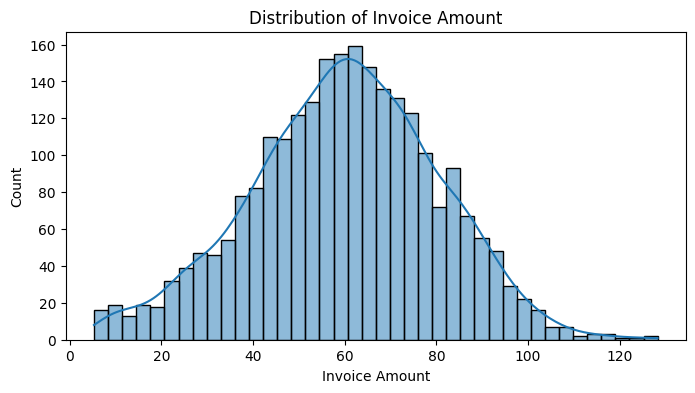

In [597]:
# ============================================================
# STEP 9A: DISTRIBUTION OF INVOICE AMOUNT
# ============================================================

plt.figure(figsize=(8, 4))
sns.histplot(model_df[invoice_amount_col], bins=40, kde=True)
plt.title("Distribution of Invoice Amount")
plt.xlabel("Invoice Amount")
plt.ylabel("Count")
plt.show()

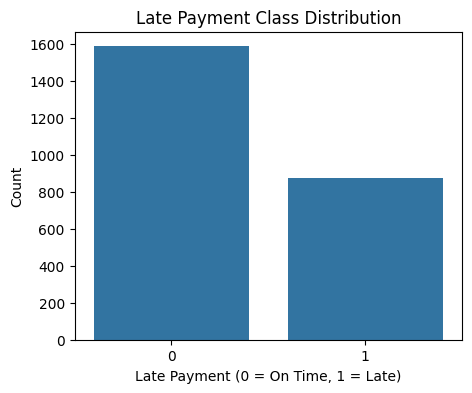

In [598]:
# ============================================================
# STEP 9B: BAR CHART OF LATE PAYMENT CLASSES
# ============================================================

plt.figure(figsize=(5, 4))
sns.countplot(x="late_payment", data=model_df)
plt.title("Late Payment Class Distribution")
plt.xlabel("Late Payment (0 = On Time, 1 = Late)")
plt.ylabel("Count")
plt.show()

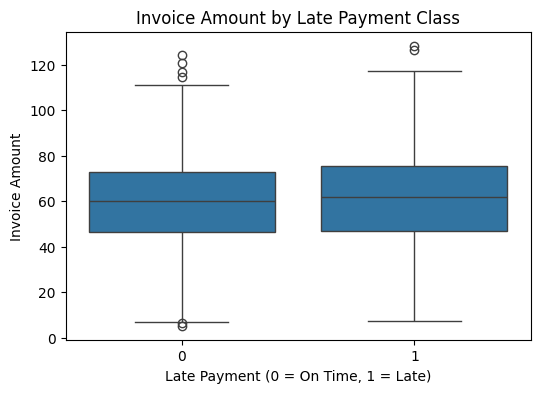

In [599]:
# ============================================================
# STEP 9C: BOXPLOT OF INVOICE AMOUNT VS LATE PAYMENT
# ============================================================

plt.figure(figsize=(6, 4))
sns.boxplot(x="late_payment", y=invoice_amount_col, data=model_df)
plt.title("Invoice Amount by Late Payment Class")
plt.xlabel("Late Payment (0 = On Time, 1 = Late)")
plt.ylabel("Invoice Amount")
plt.show()

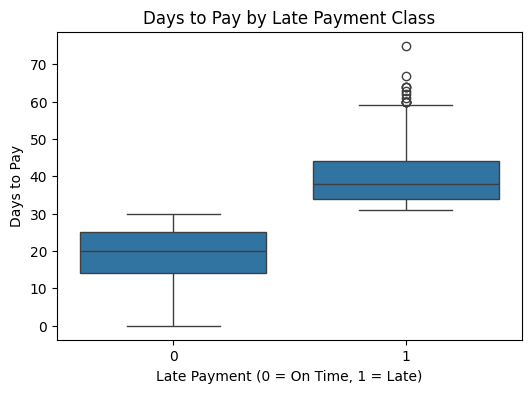

In [600]:
# ============================================================
# STEP 9D: BOXPLOT OF DAYS TO PAY VS LATE PAYMENT
# ============================================================

plt.figure(figsize=(6, 4))
sns.boxplot(x="late_payment", y="days_to_pay", data=model_df)
plt.title("Days to Pay by Late Payment Class")
plt.xlabel("Late Payment (0 = On Time, 1 = Late)")
plt.ylabel("Days to Pay")
plt.show()

## 1. Binary Classification

The goal is to predict:
- `late_payment = 1` if the invoice was paid late
- `late_payment = 0` if the invoice was paid on time

### Step 10. Select Features and Target

In [601]:
X = df[selected_feature_cols]
y = df['is_late']

print("Selected features:")
print(selected_feature_cols)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Selected features:
['InvoiceAmount', 'invoice_month', 'invoice_year', 'is_disputed', 'customer_prev_invoice_count', 'customer_prev_avg_days_late', 'customer_prev_late_ratio', 'customer_prev_avg_invoice_amount', 'days_until_due', 'is_paperless']

X shape: (2466, 10)
y shape: (2466,)


### Step 11. Train-Test Split

In [602]:
# ============================================================
# STEP 11: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # input features
    y,                  # target labels
    test_size=0.2,      # 20% of the data goes to the test set
    random_state=42,    # fixed seed for reproducibility
    stratify=y          # preserve class proportions in train and test
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1972, 10)
X_test shape : (494, 10)
y_train shape: (1972,)
y_test shape : (494,)


### Step 12. Optional Feature Scaling

- Logistic: Use Feature Scaling
- Random Forest: Use Original Data

In [603]:
# ============================================================
# STEP 12: SCALE FEATURES FOR LOGISTIC REGRESSION
# ============================================================

# Create the scaler object
scaler = StandardScaler()

# Fit the scaler on the training data only, then transform both sets
# This avoids leaking information from the test set into training
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show the type/shape after scaling
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)

Scaled X_train shape: (1972, 10)
Scaled X_test shape : (494, 10)


### Step 13. Train Logistic Regression

In [604]:
# ============================================================
# STEP 13: TRAIN LOGISTIC REGRESSION
# ============================================================

# Create the Logistic Regression model
# max_iter is increased in case the default is not enough for convergence
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the scaled training data
log_model.fit(X_train_scaled, y_train)

# Predict class labels on the test set
y_pred_log = log_model.predict(X_test_scaled)

# Predict class probabilities on the test set
# We use probabilities for AUC computation
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training complete.")

Logistic Regression training complete.


#### Step 14. Evaluate Logistic Regression

In [605]:
# ============================================================
# STEP 14A: CLASSIFICATION REPORT FOR LOGISTIC REGRESSION
# ============================================================

print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred_log))

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       318
           1       0.83      0.77      0.80       176

    accuracy                           0.86       494
   macro avg       0.85      0.84      0.85       494
weighted avg       0.86      0.86      0.86       494



Confusion Matrix:
[[290  28]
 [ 41 135]]


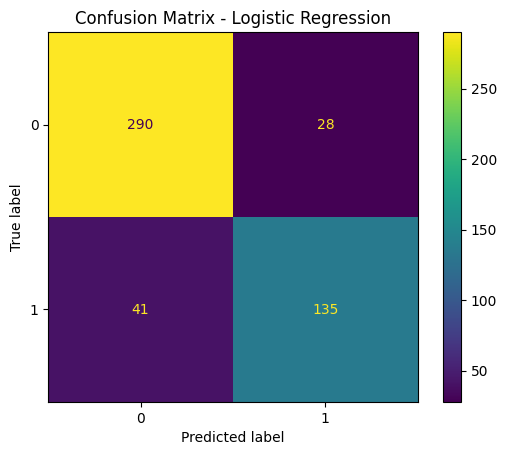

In [606]:
# ============================================================
# STEP 14B: CONFUSION MATRIX FOR LOGISTIC REGRESSION
# ============================================================

cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

ROC AUC (Logistic Regression): 0.938


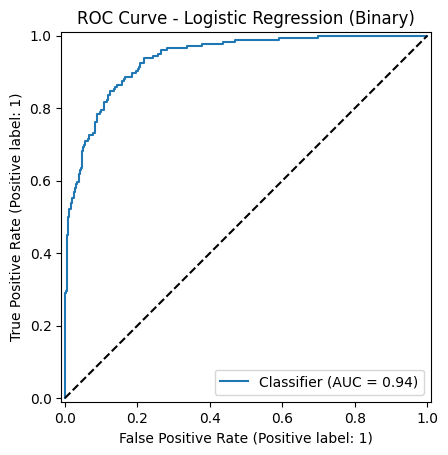

In [607]:
# ============================================================
# STEP 14C: ROC AUC FOR LOGISTIC REGRESSION
# ============================================================

auc_log = roc_auc_score(y_test, y_prob_log)
print("ROC AUC (Logistic Regression):", round(auc_log, 4))

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob_log)
plt.title("ROC Curve - Logistic Regression (Binary)")
plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.show()

#### Modify Logistic Regression Training
Add the `class_weight='balanced'` parameter

In [608]:
# ============================================================
# STEP 13-REDO: TRAIN LOGISTIC REGRESSION
# ============================================================

# Create the Logistic Regression model
# max_iter is increased in case the default is not enough for convergence
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Train the model using the scaled training data
log_model.fit(X_train_scaled, y_train)

# Predict class labels on the test set
y_pred_log = log_model.predict(X_test_scaled)

# Predict class probabilities on the test set
# We use probabilities for AUC computation
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [609]:
# ============================================================
# STEP 14-Redo.A: CLASSIFICATION REPORT FOR LOGISTIC REGRESSION
# ============================================================

print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred_log))

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       318
           1       0.77      0.86      0.81       176

    accuracy                           0.86       494
   macro avg       0.84      0.86      0.85       494
weighted avg       0.87      0.86      0.86       494



Confusion Matrix:
[[272  46]
 [ 24 152]]


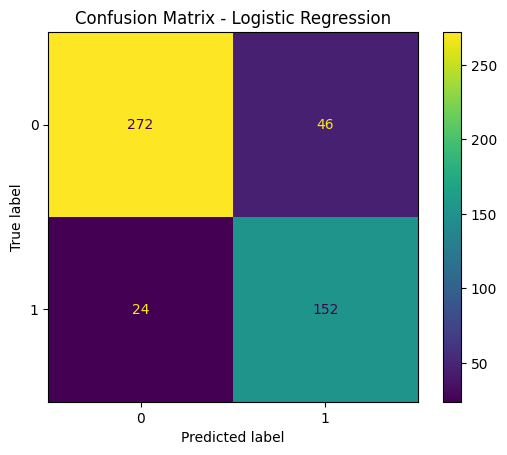

In [610]:
# ============================================================
# STEP 14-Redo.B: CONFUSION MATRIX FOR LOGISTIC REGRESSION
# ============================================================

cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

ROC AUC (Logistic Regression): 0.9388


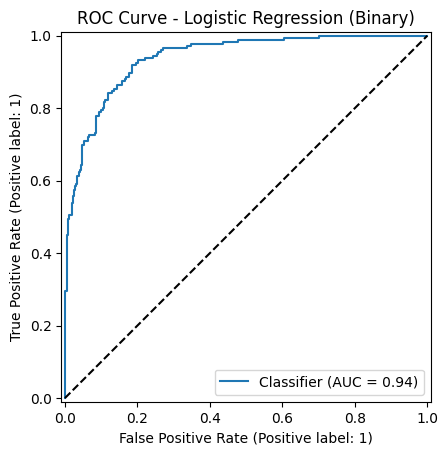

In [611]:
auc_log = roc_auc_score(y_test, y_prob_log)
print("ROC AUC (Logistic Regression):", round(auc_log, 4))

RocCurveDisplay.from_predictions(y_test, y_prob_log)
plt.title("ROC Curve - Logistic Regression (Binary)")
plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.show()

### Step 15. Train Random Forest


In [612]:
# ============================================================
# STEP 15: TRAIN RANDOM FOREST
# ============================================================

# Create the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,   # number of trees
    random_state=42,
    class_weight="balanced"  # helpful if classes are imbalanced
)

# Train the model using the original (unscaled) training data
rf_model.fit(X_train, y_train)

# Predict class labels on the test set
y_pred_rf = rf_model.predict(X_test)

# Predict class probabilities for AUC computation
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest training complete.")

Random Forest training complete.


#### Step 16. Evaluate Random Forest

We use the same evaluation approach so that we can compare models fairly.

In [613]:
# ============================================================
# STEP 16A: CLASSIFICATION REPORT FOR RANDOM FOREST
# ============================================================

print("Classification Report: Random Forest")
print(classification_report(y_test, y_pred_rf))

Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       318
           1       0.80      0.82      0.81       176

    accuracy                           0.86       494
   macro avg       0.85      0.86      0.85       494
weighted avg       0.87      0.86      0.86       494



Confusion Matrix:
[[282  36]
 [ 31 145]]


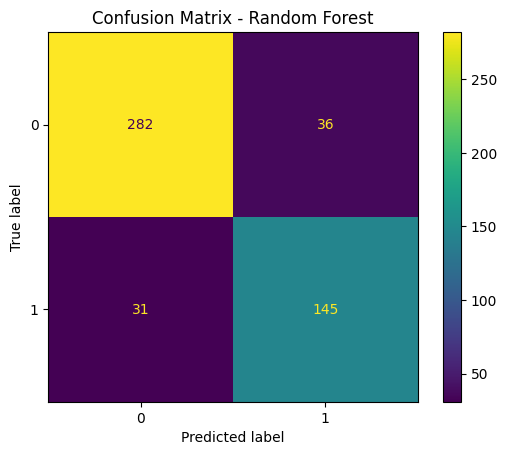

In [614]:
# ============================================================
# STEP 16B: CONFUSION MATRIX FOR RANDOM FOREST
# ============================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

ROC AUC (Random Forest): 0.9234


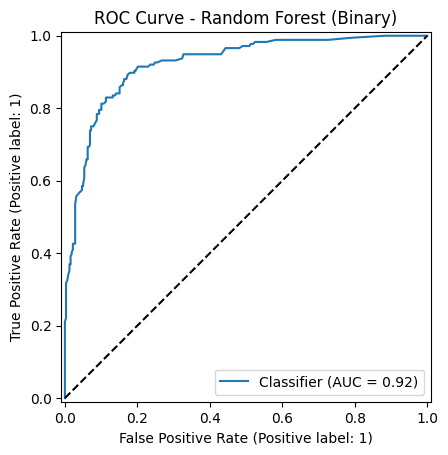

In [615]:
# ============================================================
# STEP 16C: ROC AUC FOR RANDOM FOREST
# ============================================================

auc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC AUC (Random Forest):", round(auc_rf, 4))

RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve - Random Forest (Binary)")
plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.show()

### Step 17. Compare the Two Models

In [616]:
# ============================================================
# STEP 17: COMPARE MODEL AUC SCORES
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC_AUC": [auc_log, auc_rf]
})

comparison_df

,Model,ROC_AUC
0,Logistic Regression,0.938751
1,Random Forest,0.923367


### Step 18. Interpret Feature Importance

========== RandomForestClassifier ==========
Feature importance:
customer_prev_avg_days_late         0.305359
customer_prev_late_ratio            0.235986
InvoiceAmount                       0.122453
customer_prev_avg_invoice_amount    0.096785
is_disputed                         0.093826
customer_prev_invoice_count         0.064178
invoice_month                       0.052649
is_paperless                        0.021093
invoice_year                        0.007671
days_until_due                      0.000000
dtype: float64


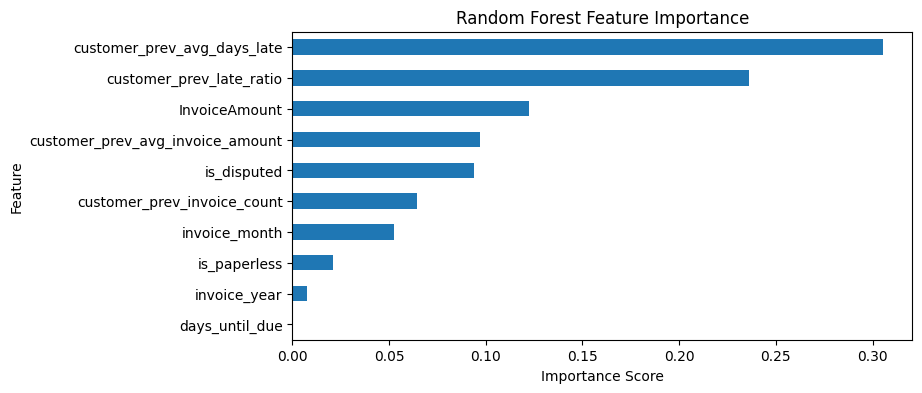

========== Logistic Regression ==========
Feature importance:
customer_prev_avg_days_late         2.007461
is_disputed                         1.003740
is_paperless                        0.485398
customer_prev_late_ratio            0.194905
invoice_year                        0.143380
InvoiceAmount                       0.090382
customer_prev_invoice_count         0.076343
customer_prev_avg_invoice_amount    0.075864
invoice_month                       0.050100
days_until_due                      0.000000
dtype: float64


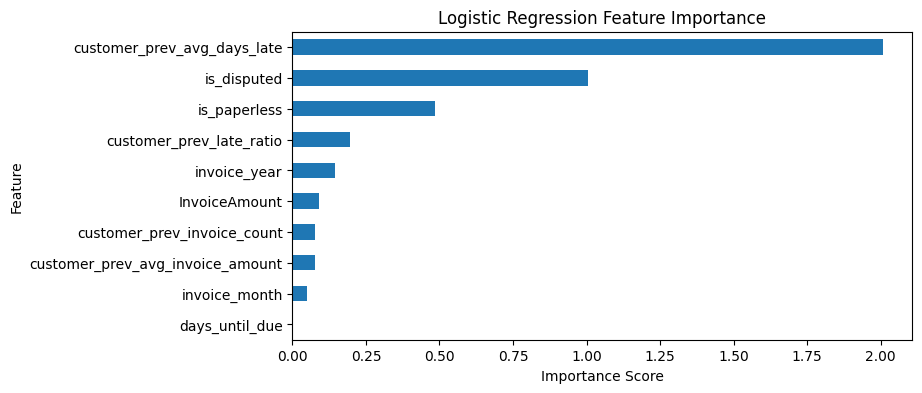

In [617]:
# ============================================================
# STEP 18: FEATURE IMPORTANCE
# ============================================================
print("="*10,"RandomForestClassifier","="*10)
# Create a Series mapping each feature name to its importance score
randomforest_importance = pd.Series(
    rf_model.feature_importances_,
    index=selected_feature_cols
).sort_values(ascending=False)

print("Feature importance:")
print(randomforest_importance)

# Plot the feature importances
plt.figure(figsize=(8, 4))
randomforest_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

print("="*10,"Logistic Regression","="*10)
log_importance = pd.Series(
    np.abs(log_model.coef_).mean(axis=0),
    index=selected_feature_cols
).sort_values(ascending=False).head(10)

print("Feature importance:")
print(log_importance)

# Plot the feature importances
plt.figure(figsize=(8, 4))
log_importance.sort_values().plot(kind="barh")
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### For Explain in Report: Decision Tree For Show How user make Decision

In [618]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(min_samples_leaf=20, max_depth=8, class_weight='balanced')
#tree = DecisionTreeClassifier(max_depth=8, class_weight='balanced')
tree.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=20)

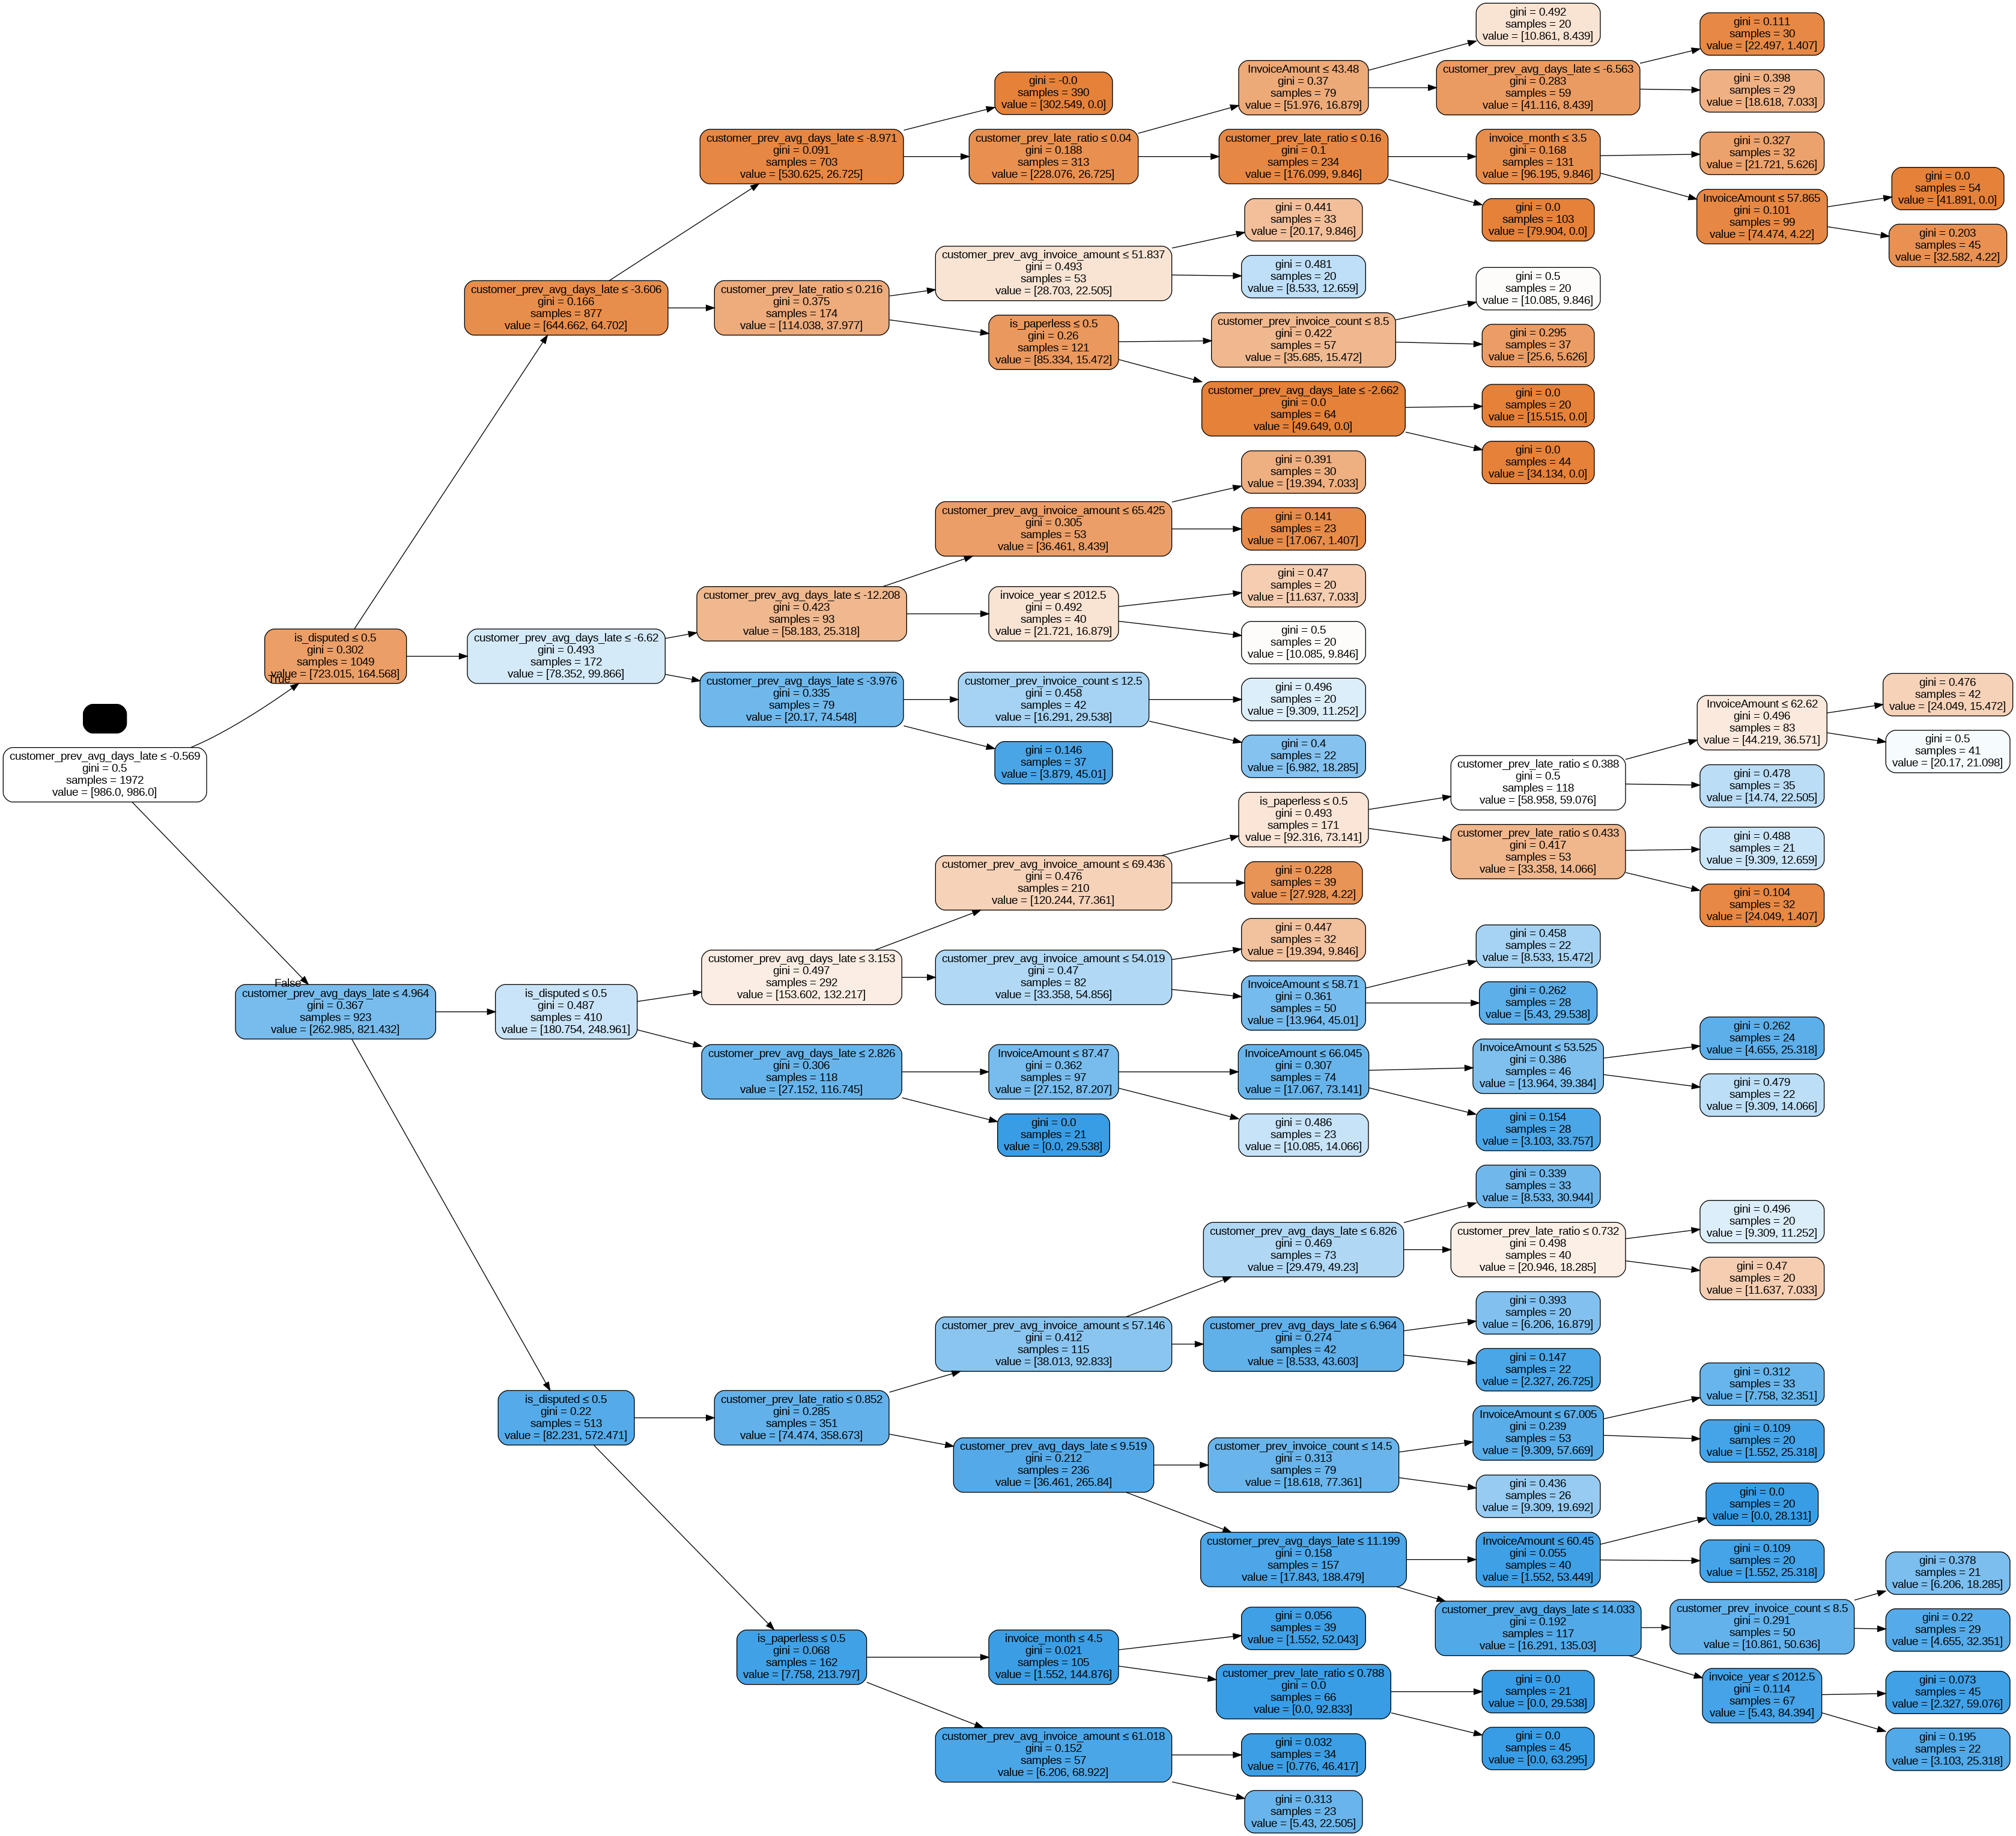

In [619]:
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(tree, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                rotate=True,
                feature_names=X_train.columns)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('tree.png')
Image(graph.create_png())

### **Discussion about Binary Classification Result:**
**ROC AUC:**
  *  Both models achieved excellent AUC scores above 0.92, indicating strong discriminative ability between late and on-time payments. Notably, Logistic Regression slightly outperformed Random Forest, which is somewhat unexpected given that Random Forest is generally the stronger model for structured tabular data.
  *  At FPR ≈ 0.2, Logistic Regression achieves TPR > 0.90, while Random Forest falls just below 0.90. This gap suggests that the relationship between the engineered features and the target is largely linear, a condition where Logistic Regression has a natural advantage. The high AUC across both models also suggests the features carry strong and consistent signal, with relatively clean class separation rather than heavily overlapping distributions.

---

**Confusion Matrix**
  * Both models perform well overall. However, they make different types of errors. Logistic Regression produces more False Positives (46 vs 36) than Random Forest it predicts some on-time invoices as late. In a collections context, this means unnecessary follow-up on invoices that would have been paid on time, which wastes resources and may damage customer relationships.
  * Random Forest, on the other hand, produces more False Negatives (31 vs 24), it misses some late invoices and predicts them as on-time. This is the more dangerous error in AR (Accounts Receivable) management, since a missed late invoice means no early intervention and potential cash flow impact.

The trade-off between these two error types depends on business priority: if the cost of missing a late payment is higher than the cost of unnecessary follow-up, Random Forest's lower FP but higher FN profile needs to be considered carefully

---

**Feature Importance**
The two models weight features differently. 
* Random Forest assigns the highest importance to customer history features (`customer_prev_avg_days_late`, `customer_prev_late_ratio`), reflecting its ability to capture non-linear interactions between behavioral signals. 
* Logistic Regression, by contrast, relies more on raw invoice-level features such as `is_disputed` 
and `is_paperless`. This is consistent with how each model works internally

Random Forest can combine multiple weak history signals into strong decision boundaries, while Logistic Regression fits a single linear boundary and responds more directly to individually scaled features. This difference explains why Random Forest is generally preferred for ERP-style data in practice, even though Logistic Regression performed slightly better on AUC here.

## 2. Multi-Class Classification
The goal is to predict:

- `payment_delay = 0` : On-time
- `payment_delay = 1` : Late 1 - 30 days
- `payment_delay = 2` : Late 31 - 60 days
- `payment_delay = 3` : Late > 60 days

### Step 19. Feature Engineering For Multiclass

In [620]:
# Convert the numeric delay into AR-style payment buckets
# These labels become the multiclass target variable
def classify_payment_bucket(x):
    if x <= 0:
        return 0
    elif x <= 30:
        return 1
    elif x <= 60:
        return 2
    else:
        return 3
    
df["payment_delay"] = df["days_late"].apply(classify_payment_bucket)
# Check how many invoices fall into each bucket
df["payment_delay"].value_counts()

,count
payment_delay,
0,1589
1,869
2,8


In [621]:
X = df[selected_feature_cols]
y = df['payment_delay']

### Step 20. Train-Test Split

In [622]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # input features
    y,                  # target labels
    test_size=0.2,      # 20% of the data goes to the test set
    random_state=42,    # fixed seed for reproducibility
    stratify=y          # preserve class proportions in train and test
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1972, 10)
X_test shape : (494, 10)
y_train shape: (1972,)
y_test shape : (494,)


### Step 21. Optional Feature Scaling

- Logistic: Use Feature Scaling
- Random Forest: Use Original Data

In [623]:
# Create the scaler object
scaler = StandardScaler()

# Fit the scaler on the training data only, then transform both sets
# This avoids leaking information from the test set into training
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show the type/shape after scaling
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)

Scaled X_train shape: (1972, 10)
Scaled X_test shape : (494, 10)


### Step 22. Logistic Regression Model

In [624]:
# Create the Logistic Regression model
# max_iter is increased in case the default is not enough for convergence
log_model = LogisticRegression(max_iter=1000, multi_class="auto", random_state=42, class_weight='balanced')

# Train the model using the scaled training data
log_model.fit(X_train_scaled, y_train)

# Predict class labels on the test set
y_pred_log = log_model.predict(X_test_scaled)

# Predict class probabilities on the test set
# We use probabilities for AUC computation
y_prob_log = log_model.predict_proba(X_test_scaled)

print("Logistic Regression training complete.")

Logistic Regression training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [625]:
from sklearn.metrics import classification_report, confusion_matrix

map_name = {0: 'On-time', 1: 'Late 1 - 30 days', 2 : 'Late 31 - 60 days', 3: 'Late > 60 days'}

true_names = y_test.map(map_name)
pred_names = [map_name[val] for val in y_pred_log]
print("Classification Report:")
print(classification_report(true_names, pred_names))
print("Confusion Matrix:")
print(confusion_matrix(true_names, pred_names))

Classification Report:
                   precision    recall  f1-score   support

 Late 1 - 30 days       0.75      0.72      0.74       174
Late 31 - 60 days       0.08      1.00      0.15         2
          On-time       0.91      0.86      0.88       318

         accuracy                           0.81       494
        macro avg       0.58      0.86      0.59       494
     weighted avg       0.85      0.81      0.83       494

Confusion Matrix:
[[126  20  28]
 [  0   2   0]
 [ 42   2 274]]


Confusion Matrix:
[[274  42   2]
 [ 28 126  20]
 [  0   0   2]]


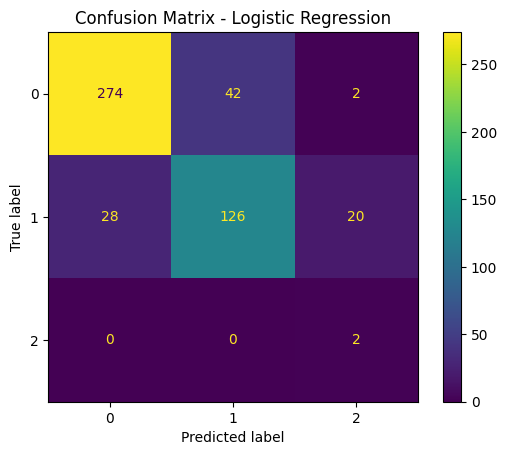

In [626]:
cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

ROC AUC (Logistic Regression): 0.9307


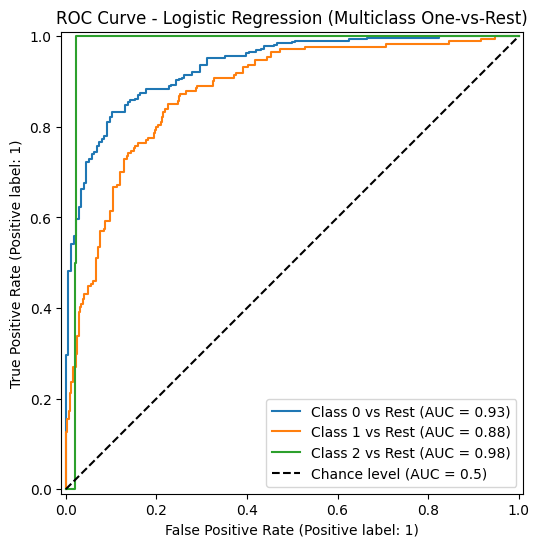

In [627]:
from sklearn.preprocessing import LabelBinarizer

auc_log = roc_auc_score(
    y_test, 
    y_prob_log, 
    multi_class='ovr',  # or 'ovo'
    average='macro'
)

print("ROC AUC (Logistic Regression):", round(auc_log, 4))

label_binarizer = LabelBinarizer()
y_test_bin = label_binarizer.fit_transform(y_test)

fig, ax = plt.subplots(figsize=(8, 6))

for i, class_label in enumerate(label_binarizer.classes_):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_prob_log[:, i],
        name=f"Class {class_label} vs Rest",
        ax=ax
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")

plt.title("ROC Curve - Logistic Regression (Multiclass One-vs-Rest)")
plt.legend()
plt.show()

### Step 23. Random Forest Model

In [628]:
# Create the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,   # number of trees
    random_state=42,
    class_weight="balanced"  # helpful if classes are imbalanced
)

# Train the model using the original (unscaled) training data
rf_model.fit(X_train, y_train)

# Predict class labels on the test set
y_pred_rf = rf_model.predict(X_test)

# Predict class probabilities for AUC computation
y_prob_rf = rf_model.predict_proba(X_test)

print("Random Forest training complete.")

Random Forest training complete.


In [629]:
print("Classification Report: Random Forest")
print(classification_report(y_test, y_pred_rf))

Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       318
           1       0.76      0.78      0.77       174
           2       0.00      0.00      0.00         2

    accuracy                           0.84       494
   macro avg       0.55      0.55      0.55       494
weighted avg       0.84      0.84      0.84       494



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix:
[[278  40   0]
 [ 38 136   0]
 [  0   2   0]]


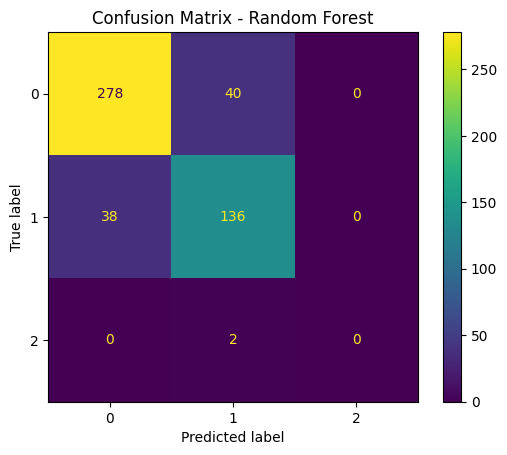

In [630]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

ROC AUC (Random Forest): 0.8373


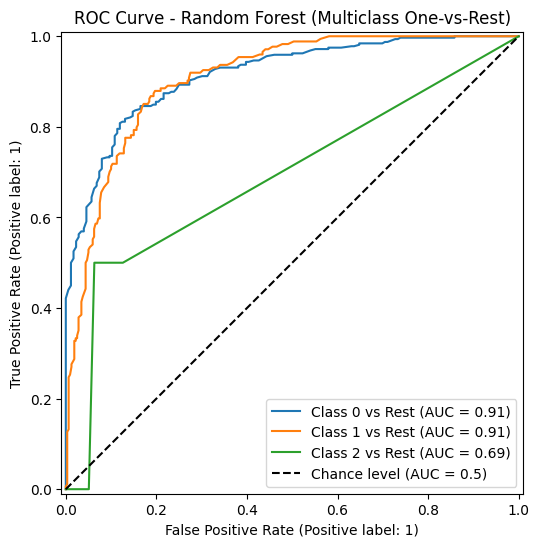

In [631]:
auc_rf = roc_auc_score(
    y_test, 
    y_prob_rf, 
    multi_class='ovr',  # or 'ovo'
    average='macro'
)
print("ROC AUC (Random Forest):", round(auc_rf, 4))

y_test_bin = label_binarizer.fit_transform(y_test)

fig, ax = plt.subplots(figsize=(8, 6))

for i, class_label in enumerate(label_binarizer.classes_):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_prob_rf[:, i],
        name=f"Class {class_label} vs Rest",
        ax=ax
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")

plt.title("ROC Curve - Random Forest (Multiclass One-vs-Rest)")
plt.legend()
plt.show()

### Step 24. Compare the Two Models

In [632]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC_AUC": [auc_log, auc_rf]
})

comparison_df

,Model,ROC_AUC
0,Logistic Regression,0.930704
1,Random Forest,0.837258


### Step 25. Interpret Feature Importance

========== RandomForestClassifier ==========
Feature importance:
customer_prev_avg_days_late         0.261799
customer_prev_late_ratio            0.168636
InvoiceAmount                       0.156388
is_disputed                         0.111642
customer_prev_avg_invoice_amount    0.102886
invoice_month                       0.091331
customer_prev_invoice_count         0.076334
is_paperless                        0.021746
invoice_year                        0.009237
days_until_due                      0.000000
dtype: float64


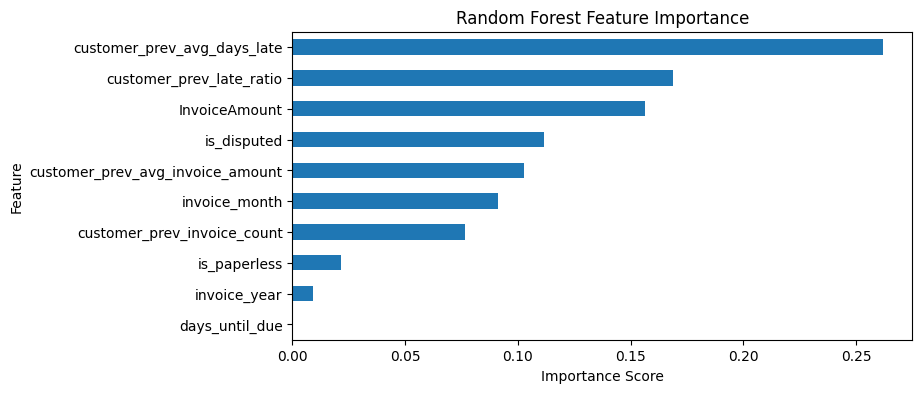

========== Logistic Regression ==========
Feature importance:
customer_prev_avg_days_late         2.279958
invoice_year                        1.518795
customer_prev_invoice_count         1.434452
invoice_month                       0.995593
is_disputed                         0.826698
customer_prev_late_ratio            0.744664
is_paperless                        0.439126
InvoiceAmount                       0.075660
customer_prev_avg_invoice_amount    0.049899
days_until_due                      0.000000
dtype: float64


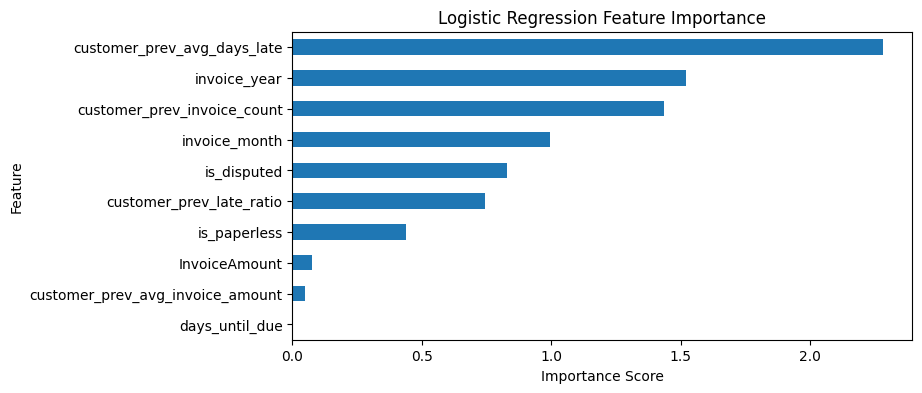

In [633]:
print("="*10,"RandomForestClassifier","="*10)
# Create a Series mapping each feature name to its importance score
randomforest_importance = pd.Series(
    rf_model.feature_importances_,
    index=selected_feature_cols
).sort_values(ascending=False)

print("Feature importance:")
print(randomforest_importance)

# Plot the feature importances
plt.figure(figsize=(8, 4))
randomforest_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

print("="*10,"Logistic Regression","="*10)
log_importance = pd.Series(
    np.abs(log_model.coef_).mean(axis=0),
    index=selected_feature_cols
).sort_values(ascending=False).head(10)

print("Feature importance:")
print(log_importance)

# Plot the feature importances
plt.figure(figsize=(8, 4))
log_importance.sort_values().plot(kind="barh")
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### For Explain in Report: Decision Tree For Show How user make Decision

In [634]:
tree = DecisionTreeClassifier(min_samples_leaf=20, max_depth=8, class_weight='balanced')

tree.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=20)

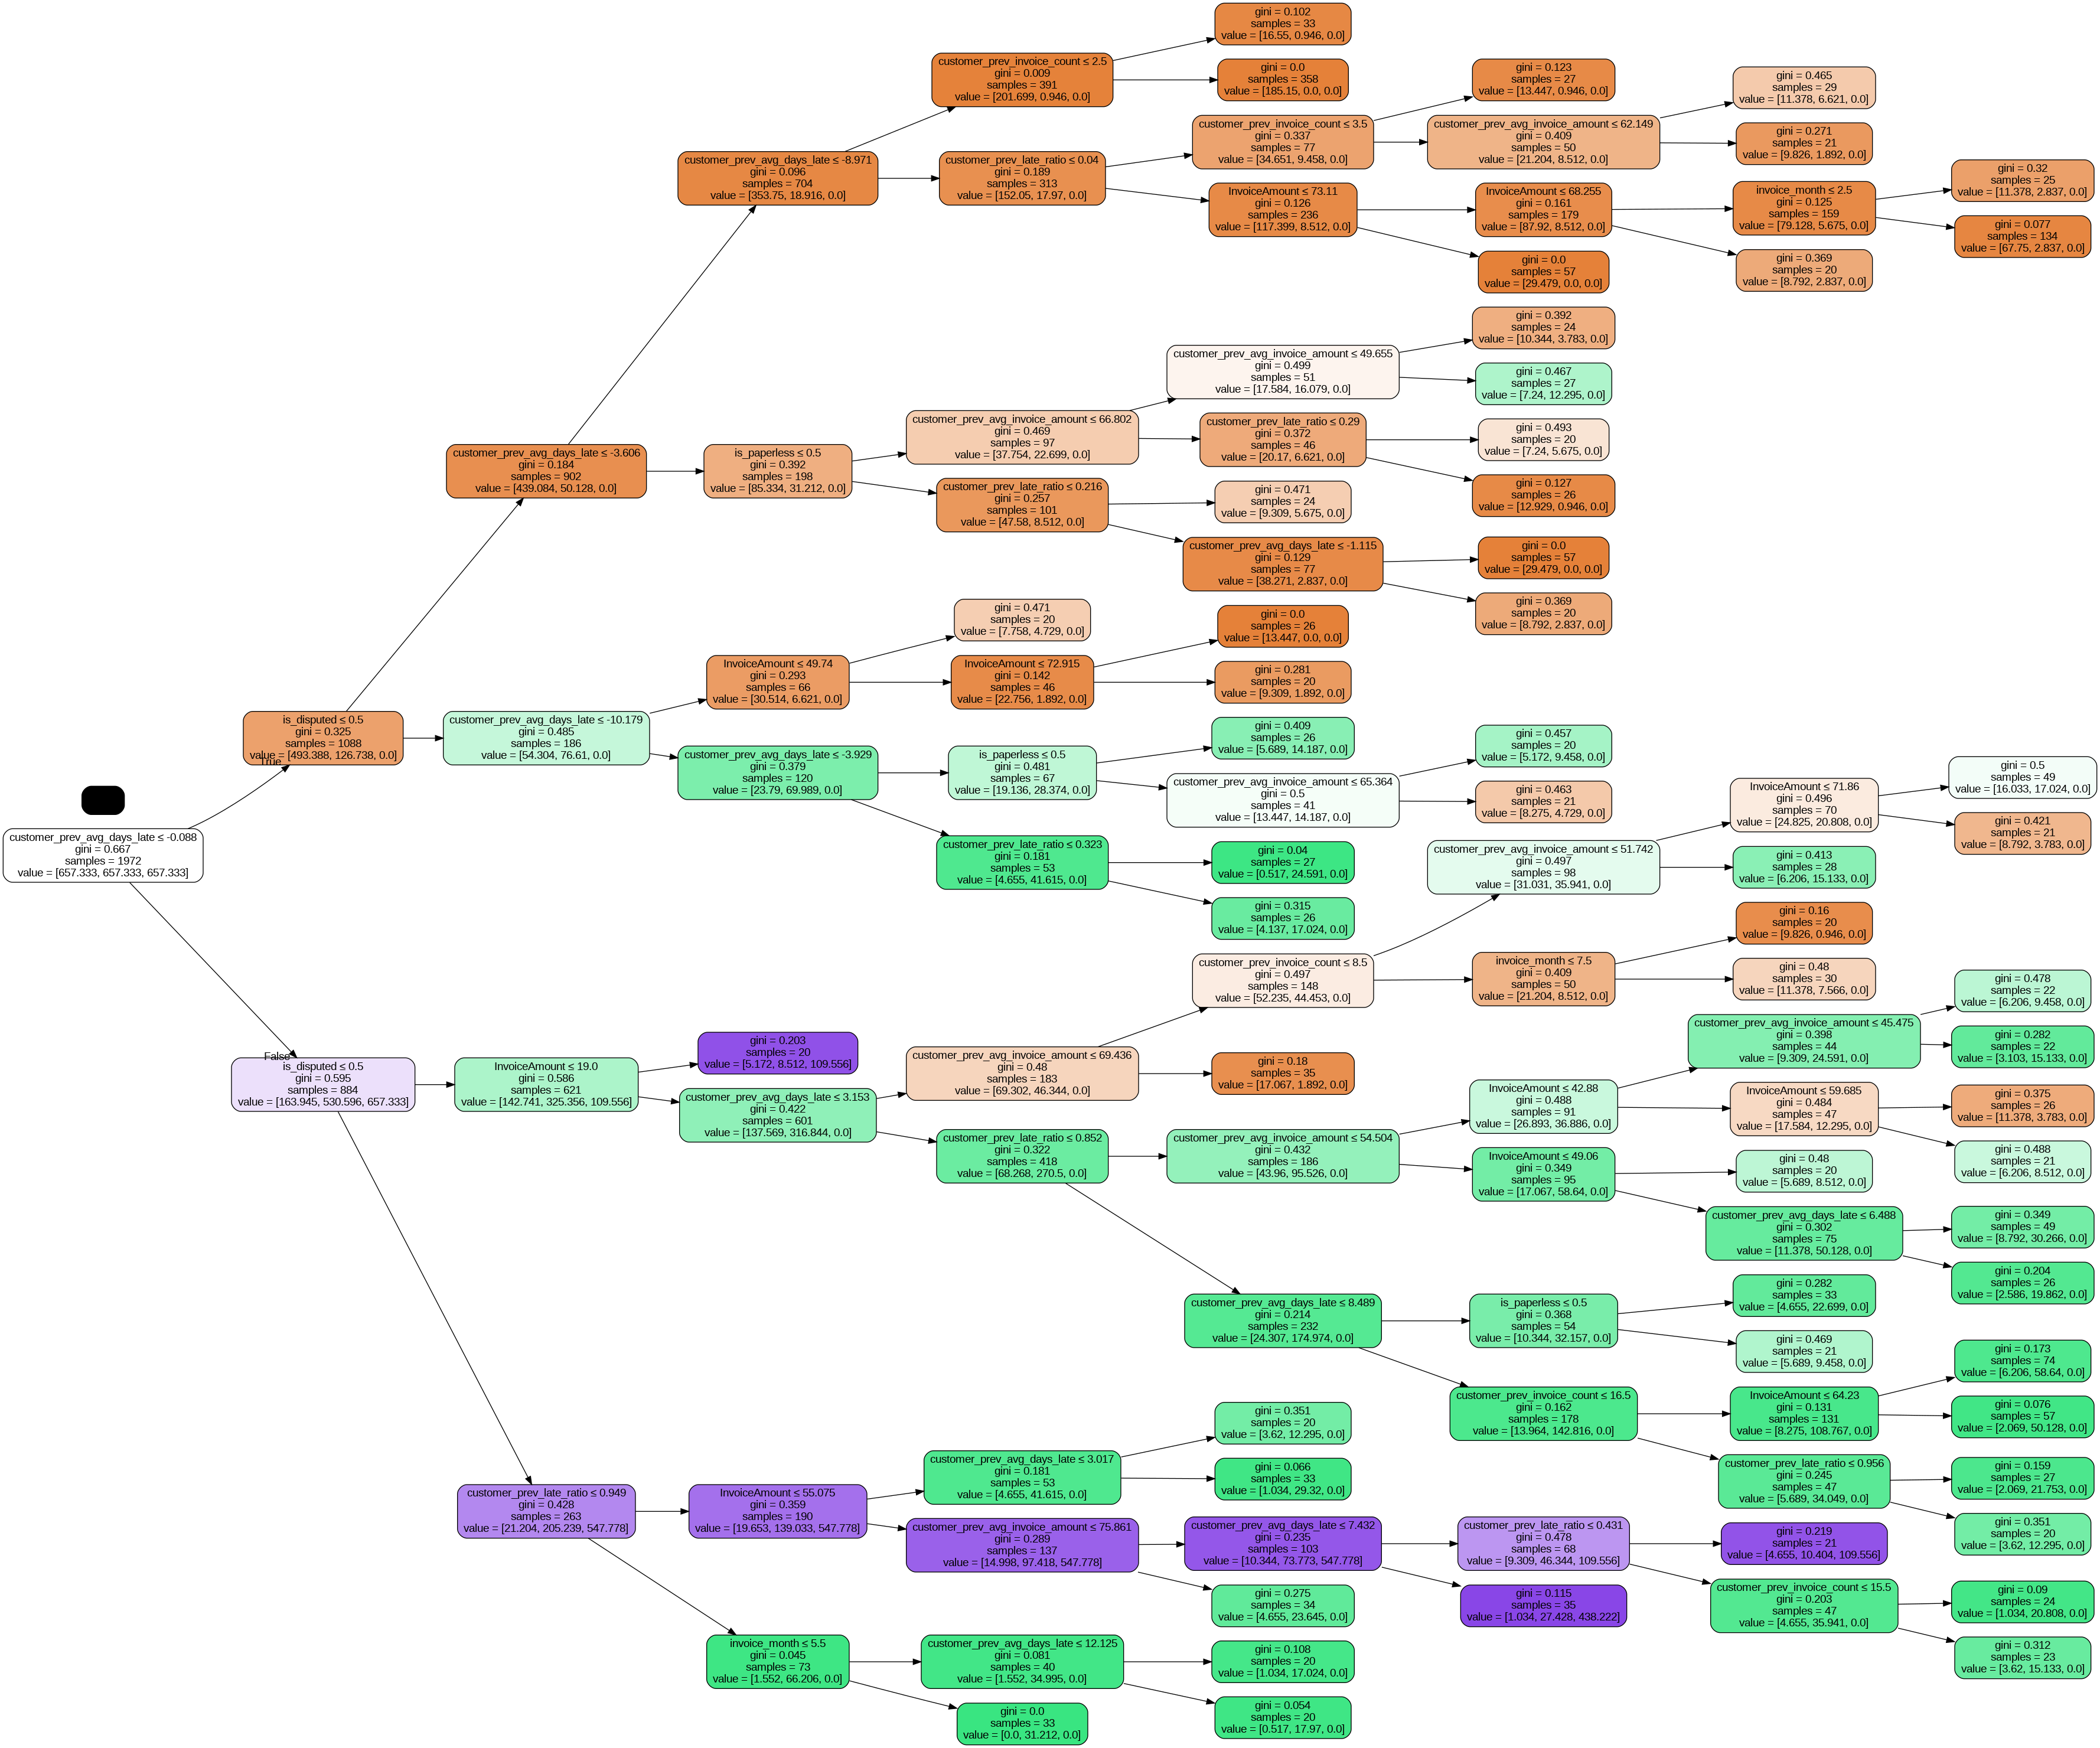

In [635]:
dot_data = StringIO()
export_graphviz(tree, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                rotate=True,
                feature_names=X_train.columns)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('tree.png')
Image(graph.create_png())

### **Discussion about Multi-Class Classification Result:**

**Class Distribution (Imbalance)**\
After applying the payment delay categorization, the dataset produced only 3 distinct classes:
- Class 0 (On-time): 1,589 samples (64.44%)
- Class 1 (Late 1–30 days): 869 samples (35.24%)
- Class 2 (Late 31–60 days): 8 samples (0.32%)
- Class 3 (Late > 60 days): 0 samples (absent from this dataset)

Class 3 is entirely absent, meaning no invoice in this dataset was paid more than 
60 days late. This suggests the IBM dataset represents a relatively low-risk 
customer base, or that severely overdue invoices were already written off before 
appearing in the AR records.

This also means the problem effectively reduces to a 3-class classification, with Class 2 being critically underrepresented at only 8 samples.

---

**ROC AUC:**
* Random Forest: performs well on Classes 0 and 1, which dominate the dataset. However, its AUC for Class 2 is poor, reflecting the model's inability to generalize from only 8 training samples,there is simply not enough data for the ensemble of trees to find a consistent pattern.

* Logistic Regression: shows relatively better AUC on Class 2 compared to Random Forest. A possible explanation is that Class 2 (31–60 days late) may be linearly separable from the other classes in feature space, meaning the boundary between "moderately late" and other categories can be captured by a simple linear decision surface, which favors Logistic Regression.

---

**Confusion Matrix**\
Both models handle Class 0 and Class 1 reasonably well, but their behavior on Class 2 reveals a fundamental difference in how each model responds to severe class imbalance.

* Random Forest correctly predicts 0 out of 8 Class 2 invoices, it completely fails to identify any moderately late invoice (31–60 days). Instead, it absorbs all Class 2 samples into Class 1, treating them as merely short-term late. This is a common failure mode for tree-based models under extreme imbalance: with only 8 samples, no tree in the ensemble sees enough Class 2 examples to create a reliable split for it.

* Logistic Regression, surprisingly, correctly identifies 2 out of 8 Class 2 invoices. While still poor in absolute terms, this is notable — it suggests that Class 2 invoices occupy a somewhat distinct region in the linear feature space, consistent with the earlier observation that Class 2 may be partially linearly separable. However, LR also misclassifies 20 Class 1 invoices as Class 2, producing more false alarms for the moderate-late category.

---

**Feature Importance**
The two models weight features differently. 
* Random Forest assigns the highest importance to customer history features (`customer_prev_avg_days_late`, `customer_prev_late_ratio`), reflecting its ability to capture non-linear interactions between behavioral signals. 
* Logistic Regression, by contrast, relies more on raw invoice-level features such as `invoice_month` 
and `invoice_year`. This is consistent with how each model works internally

Random Forest can combine multiple weak history signals into strong decision boundaries, while Logistic Regression fits a single linear boundary and responds more directly to individually scaled features. This difference explains why Random Forest is generally preferred for ERP-style data in practice, even though Logistic Regression performed slightly better on AUC here.

---

**Business Implication:**\
The severe underrepresentation of Class 2 (and potentially Class 3) means this model should not be trusted to predict moderate-to-severe lateness in production. To improve multiclass performance, collecting more data for rare delay categories or merging Class 2 and Class 3 into a single "severely late" bucket would be recommended.